Признаков: 17, Объектов в train: 800, Объектов в test: 200
Epoch 20/100 — Train Loss: 0.0857, Val Loss: 0.1349
Epoch 40/100 — Train Loss: 0.0375, Val Loss: 0.1200
Epoch 60/100 — Train Loss: 0.0203, Val Loss: 0.1177
Epoch 80/100 — Train Loss: 0.0125, Val Loss: 0.1704
Epoch 100/100 — Train Loss: 0.0114, Val Loss: 0.1554
Оценка
Accuracy:  0.9625
Precision: 0.9600
Recall:    0.8276
F1-score:  0.8889
ROC-AUC:   0.9868
   patient_id  prediction
0           2           0
1           3           0
2           8           0
3          18           0
4          19           0


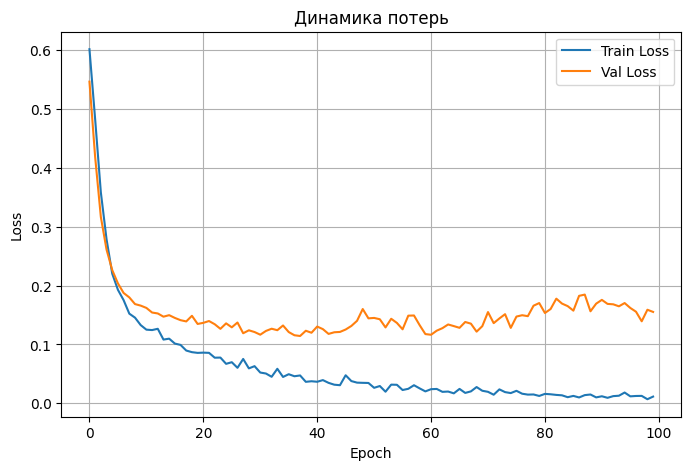

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

train_df = pd.read_csv('/content/sample_data/train.csv')
test_df = pd.read_csv('/content/sample_data/test_features.csv')

#целевая перемнная
target_col = 'prediction'
#id признак
test_patient_ids = test_df['patient_id']
X_test_raw = test_df.drop(columns=['patient_id'])

X = train_df.drop(columns=['patient_id', target_col]).values.astype(np.float32)
y = train_df[target_col].values.astype(np.float32).reshape(-1, 1)

X_test_raw = X_test_raw.values.astype(np.float32)

print(f"Признаков: {X.shape[1]}, Объектов в train: {X.shape[0]}, Объектов в test: {X_test_raw.shape[0]}")

#train/test
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#нормализация
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train) # Обучаем imputer на тренировочных данных
X_val = imputer.transform(X_val)         # Применяем к валидации
X_test = imputer.transform(X_test_raw)   # Применяем к реальным тестовым данным

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#преобразование
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

#dataloader
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# определение модели
class Task1FFN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)          # линейный выход (logits)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Task1FFN(X_train.shape[1]).to(device)

#потери, оптимизатор
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# обучение
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    # train
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

# оценка модели
model.eval()
y_pred_prob = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        y_pred_prob.extend(probs.cpu().numpy().flatten())
        y_true.extend(y_batch.numpy().flatten())

y_pred_prob = np.array(y_pred_prob)
y_true = np.array(y_true)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

print("Оценка")
print(f"Accuracy:  {accuracy_score(y_true, y_pred_class):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_class):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_class):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred_class):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred_prob):.4f}")

#предсказание
X_test_t = torch.tensor(X_test, dtype=torch.float32)
test_preds = []

#dataloader
test_dataset = TensorDataset(X_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch[0].to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        test_preds.extend(probs.cpu().numpy().flatten())

# вероятности в классы
test_preds_class = (np.array(test_preds) >= 0.5).astype(int)

#dataframe для отправки
submission = pd.DataFrame({
    'patient_id': test_patient_ids,
    'prediction': test_preds_class
})

#проверка вывода
assert len(submission) == len(test_df), "Количество строк не совпадает с test_features.csv!"
assert submission['prediction'].isnull().sum() == 0, "Есть пропущенные значения в prediction!"
os.makedirs('outputs', exist_ok=True)
submission.to_csv('outputs/task1_predictions.csv', index=False)
print(submission.head())

# график потерь
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика потерь')
plt.legend()
plt.grid(True)
plt.show()